In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (운영체제별)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (Colab 등)
    # 나눔고딕 설치
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [2]:
# ── 0. 라이브러리 ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, roc_auc_score, f1_score

# ── 1. 데이터 로드 & 파생변수 (EDA 재현) ──────────────────────
df = pd.read_csv('ai4i2020.csv')
df.columns = df.columns.str.strip()

df['Temp_diff']    = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']        = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['Torque_Wear']  = df['Torque [Nm]'] * df['Tool wear [min]']
df['Type_encoded'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
df = df.rename(columns={'Tool wear [min]': 'Tool_wear_min'})

# ── 2. 피처 / 타겟 분리 ───────────────────────────────────────
FEATURES = ['Type_encoded', 'Temp_diff', 'Power', 'Torque_Wear', 'Tool_wear_min']
TARGET   = 'Machine failure'

X = df[FEATURES]
y = df[TARGET]

# ── 3. Train/Test 분할 ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. 저장된 모델 불러오기 ───────────────────────────────────
best_lgbm = joblib.load('lgbm_final.pkl')
print('모델 로드 완료!')

# ── 5. 예측 (threshold 0.70) ──────────────────────────────────
y_proba = best_lgbm.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.70).astype(int)

print(f'Recall  : {recall_score(y_test, y_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred):.4f}')

모델 로드 완료!
Recall  : 0.8529
ROC-AUC : 0.9720
F1-score: 0.6073


── 고장 유형별 발생 건수 ──
Type  Count                     Name
 RNF     19           Random Failure
 TWF     46        Tool Wear Failure
 PWF     95            Power Failure
 OSF     98       Overstrain Failure
 HDF    115 Heat Dissipation Failure


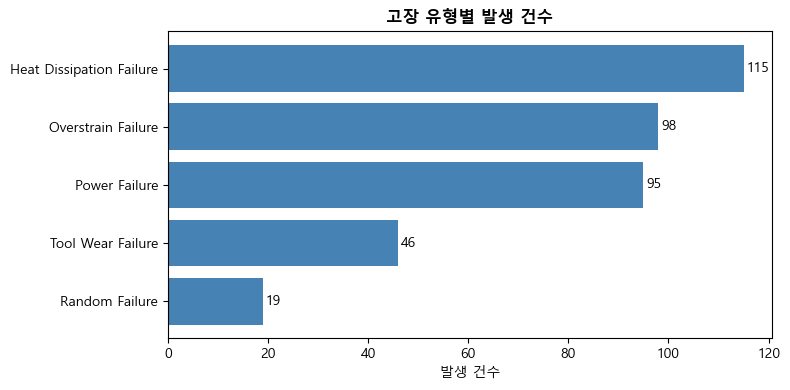


── 고장 유형별 주요 센서값 평균 ──

[ Tool Wear Failure ]
                          고장시 평균   정상시 평균       차이
Air temperature [K]       300.30   300.00     0.29
Process temperature [K]   310.17   310.00     0.16
Rotational speed [rpm]   1566.17  1538.65    27.52
Torque [Nm]                37.84    40.00    -2.16
Tool_wear_min             216.37   107.45   108.92
Temp_diff                   9.87    10.00    -0.13
Power                    6019.33  6280.95  -261.62
Torque_Wear              8188.77  4296.76  3892.01

[ Heat Dissipation Failure ]
                          고장시 평균   정상시 평균       차이
Air temperature [K]       302.56   299.98     2.59
Process temperature [K]   310.79   310.00     0.79
Rotational speed [rpm]   1337.26  1541.12  -203.86
Torque [Nm]                53.17    39.83    13.33
Tool_wear_min             107.19   107.96    -0.77
Temp_diff                   8.23    10.02    -1.79
Power                    7433.17  6266.33  1166.84
Torque_Wear              5702.38  4298.52  1403.86

[ Po

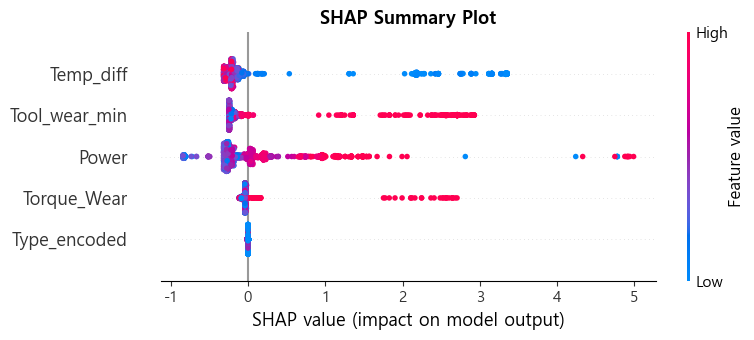

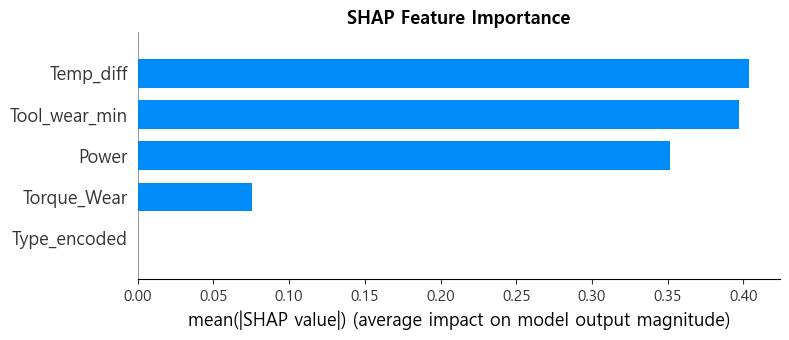

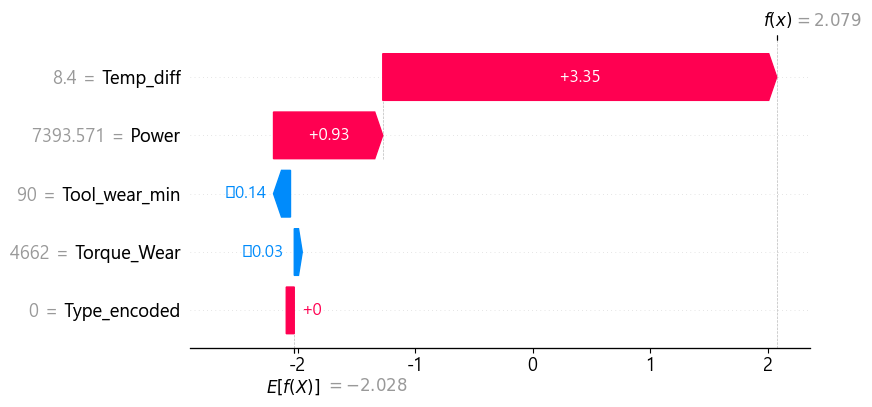


── 실무 기준 제안 ──

📌 Temp_diff   ≤ 9K           → HDF 위험 (가장 중요!)
📌 Tool_wear   ≥ 200min       → TWF 위험
📌 Power       ≥ 7000W        → PWF 위험
📌 Torque_Wear ≥ 10000        → OSF 위험



In [3]:
# ── 6. 고장 유형별 분석 ───────────────────────────────────────
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

# 6-1. 고장 유형별 발생 건수
failure_counts = df[failure_cols].sum().reset_index()
failure_counts.columns = ['Type', 'Count']
failure_counts['Name'] = failure_counts['Type'].map(failure_names)
failure_counts = failure_counts.sort_values('Count', ascending=True)

print('── 고장 유형별 발생 건수 ──')
print(failure_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(failure_counts['Name'], failure_counts['Count'], color='steelblue')
ax.set_xlabel('발생 건수')
ax.set_title('고장 유형별 발생 건수', fontweight='bold')
for i, v in enumerate(failure_counts['Count']):
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

# 6-2. 고장 유형별 센서값 평균 비교
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool_wear_min',
               'Temp_diff', 'Power', 'Torque_Wear']

print('\n── 고장 유형별 주요 센서값 평균 ──')
for col in failure_cols:
    failed = df[df[col] == 1][sensor_cols].mean()
    normal = df[df[col] == 0][sensor_cols].mean()
    diff   = failed - normal
    print(f'\n[ {failure_names[col]} ]')
    print(pd.DataFrame({
        '고장시 평균': failed,
        '정상시 평균': normal,
        '차이'      : diff
    }).round(2))

# ── 7. SHAP 분석 ──────────────────────────────────────────────
explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# 7-1. Summary Plot
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_test,
                  feature_names=FEATURES,
                  show=False)
plt.title('SHAP Summary Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 7-2. Bar Plot
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_vals, X_test,
                  feature_names=FEATURES,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 7-3. Waterfall Plot (True Positive 샘플 1개)
tp_idx = np.where((y_test.values == 1) & (y_pred == 1))[0][0]

if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[tp_idx],
        base_values=base_val,
        data=X_test.iloc[tp_idx],
        feature_names=FEATURES
    )
)

# ── 8. 실무 기준 제안 정리 ────────────────────────────────────
print('\n── 실무 기준 제안 ──')
print('''
📌 Temp_diff   ≤ 9K           → HDF 위험 (가장 중요!)
📌 Tool_wear   ≥ 200min       → TWF 위험
📌 Power       ≥ 7000W        → PWF 위험
📌 Torque_Wear ≥ 10000        → OSF 위험
''')

# 비즈니스 시나리오 설계

**코드 핵심 포인트**

- 모델 도입 전 → 고장 전부 사후 대응 (수리비 + 생산중단)
- 모델 도입 후 → 고장 85% 사전 탐지 (점검비만 발생)
             → 나머지 15% 놓친 고장 (손실 발생)
             → 오탐 건수만큼 불필요한 점검 발생



── 모델 도입 전 월 손실 ──
월 고장 건수        : 17건
건당 총 손실        : 1300만원
월 총 손실          : 22100만원

── 모델 도입 후 월 비용 ──
사전 탐지 건수      : 14건
놓친 고장 건수      : 3건
오탐 건수           : 13건
월 총 비용          : 5250만원

── 비용 절감 효과 ──
월 절감액           : 16850만원
절감률              : 76.2%
연간 절감액         : 202200만원


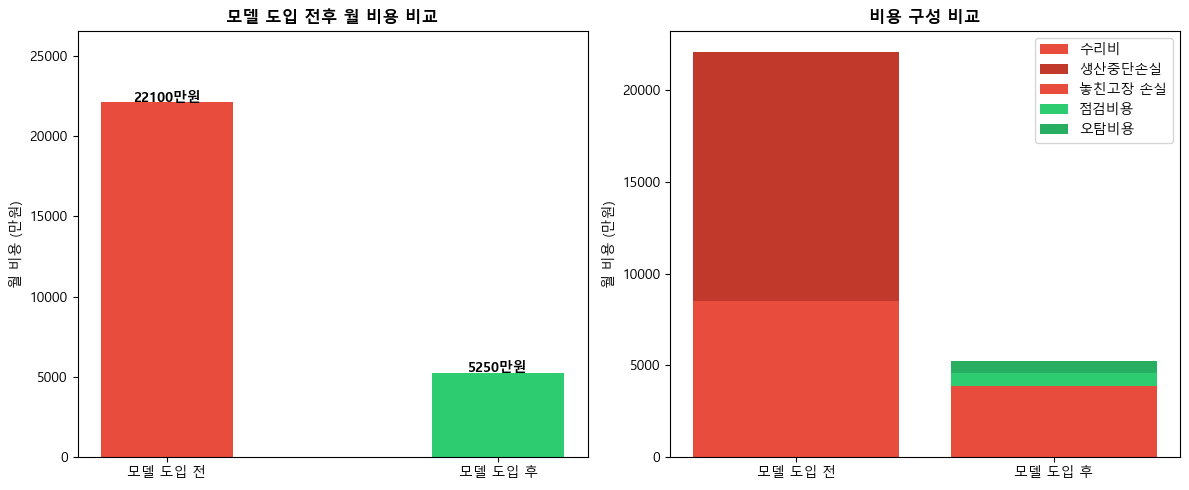


══════════════════════════════════════════
📊 비즈니스 임팩트 요약
══════════════════════════════════════════
공장 가동 기계     : 500대
월 평균 고장 건수  : 17건
고장 1건당 손실    : 1300만원
                   (수리비 500만원 + 생산중단 800만원)

[모델 도입 전]
월 총 손실         : 22100만원

[모델 도입 후]
고장 사전 탐지율   : 85% (Recall 기준)
월 총 비용         : 5250만원

💰 월 절감액       : 16850만원 (76.2% 절감)
💰 연간 절감액     : 202200만원
══════════════════════════════════════════



In [5]:
# ── 9. 비즈니스 시나리오 설계 ─────────────────────────────────

# 9-1. 가상 비용 설정
REPAIR_COST       = 500   # 고장 1건당 수리비 (만원)
DOWNTIME_COST     = 800   # 고장 1건당 생산 중단 손실 (만원, 평균 4시간 × 200만원)
INSPECTION_COST   = 50    # 예방 점검 1회당 비용 (만원)
N_MACHINES        = 500    # 공장 가동 기계 대수
FAILURE_RATE      = 0.034 # 월 고장 발생 비율 (데이터 기준 3.4%)

# 9-2. 월 기본 지표 계산
monthly_failures  = round(N_MACHINES * FAILURE_RATE)  # 월 고장 건수
total_cost_before = monthly_failures * (REPAIR_COST + DOWNTIME_COST)  # 모델 없을 때 월 손실

print('── 모델 도입 전 월 손실 ──')
print(f'월 고장 건수        : {monthly_failures}건')
print(f'건당 총 손실        : {REPAIR_COST + DOWNTIME_COST}만원')
print(f'월 총 손실          : {total_cost_before}만원')

# 9-3. 모델 도입 후 계산
# 모델 Recall 0.85 → 고장 85% 사전 탐지
# 탐지된 고장 → 예방 점검으로 대체 (수리비 + 중단 손실 절감)
# 미탐지 고장 → 그대로 손실 발생
# 오탐 → 불필요한 점검 비용 발생

RECALL       = 0.85   # 모델 Recall (CV 기준)
PRECISION    = 0.52   # 모델 Precision 추정

detected     = round(monthly_failures * RECALL)        # 사전 탐지 건수
missed       = monthly_failures - detected             # 놓친 고장 건수
false_alarms = round(detected / PRECISION * (1 - PRECISION))  # 오탐 건수

cost_after = (
    missed * (REPAIR_COST + DOWNTIME_COST) +   # 놓친 고장 손실
    detected * INSPECTION_COST +               # 탐지된 고장 점검 비용
    false_alarms * INSPECTION_COST             # 오탐 점검 비용
)

print('\n── 모델 도입 후 월 비용 ──')
print(f'사전 탐지 건수      : {detected}건')
print(f'놓친 고장 건수      : {missed}건')
print(f'오탐 건수           : {false_alarms}건')
print(f'월 총 비용          : {cost_after}만원')

# 9-4. 비용 절감 효과
saving        = total_cost_before - cost_after
saving_rate   = saving / total_cost_before * 100

print('\n── 비용 절감 효과 ──')
print(f'월 절감액           : {saving}만원')
print(f'절감률              : {saving_rate:.1f}%')
print(f'연간 절감액         : {saving * 12}만원')

# 9-5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 모델 전후 월 비용 비교
labels = ['모델 도입 전', '모델 도입 후']
costs  = [total_cost_before, cost_after]
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, costs, color=colors, width=0.4)
axes[0].set_ylabel('월 비용 (만원)')
axes[0].set_title('모델 도입 전후 월 비용 비교', fontweight='bold')
for i, v in enumerate(costs):
    axes[0].text(i, v + 50, f'{v}만원', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(costs) * 1.2)

# 비용 구성 breakdown
before_items = ['수리비', '생산중단손실']
before_vals  = [
    monthly_failures * REPAIR_COST,
    monthly_failures * DOWNTIME_COST
]

after_items = ['놓친고장 손실', '점검비용', '오탐비용']
after_vals  = [
    missed * (REPAIR_COST + DOWNTIME_COST),
    detected * INSPECTION_COST,
    false_alarms * INSPECTION_COST
]

x = np.arange(2)
width = 0.35

axes[1].bar(0, before_vals[0], color='#e74c3c', label='수리비')
axes[1].bar(0, before_vals[1], bottom=before_vals[0], color='#c0392b', label='생산중단손실')
axes[1].bar(1, after_vals[0], color='#e74c3c', label='놓친고장 손실')
axes[1].bar(1, after_vals[1], bottom=after_vals[0], color='#2ecc71', label='점검비용')
axes[1].bar(1, after_vals[2], bottom=after_vals[0]+after_vals[1], color='#27ae60', label='오탐비용')

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['모델 도입 전', '모델 도입 후'])
axes[1].set_ylabel('월 비용 (만원)')
axes[1].set_title('비용 구성 비교', fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# 9-6. 최종 스토리 출력
print(f'''
══════════════════════════════════════════
📊 비즈니스 임팩트 요약
══════════════════════════════════════════
공장 가동 기계     : {N_MACHINES}대
월 평균 고장 건수  : {monthly_failures}건
고장 1건당 손실    : {REPAIR_COST + DOWNTIME_COST}만원
                   (수리비 {REPAIR_COST}만원 + 생산중단 {DOWNTIME_COST}만원)

[모델 도입 전]
월 총 손실         : {total_cost_before}만원

[모델 도입 후]
고장 사전 탐지율   : {RECALL*100:.0f}% (Recall 기준)
월 총 비용         : {cost_after}만원

💰 월 절감액       : {saving}만원 ({saving_rate:.1f}% 절감)
💰 연간 절감액     : {saving * 12}만원
══════════════════════════════════════════
''')
